# Phase C — Logistic Regression

CRISP-DM *Modeling*. Trains **only** on the leakage-safe outputs of Phase B
(`data/processed/<scope>/X_*`, `y_*`) — **no raw data, no re-preprocessing here.**

Shared rules (see README): one-hot for `genre`/`platform_family`, ordinal handling for
`publisher_tier`, run **twice** (no resampling vs. 50/50 train-downsample), evaluate on the
untouched test set with ROC-AUC + F1 + confusion matrix, beat the majority baseline, save to
`results/logistic_regression.csv`.

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
SCOPE = "scope_2000_2018"   # primary scope (locked in Phase A/B)
DATA = f"data/processed/{SCOPE}"
MODEL_NAME = "logistic_regression"

## 1. Load processed data

Loaded **only** from `data/processed/<scope>/` — this is the leakage-safe train/test split
produced by Phase B. `meta_*` is for synthesis only and is not loaded as a feature here.

In [10]:
X_train = pd.read_csv(f"{DATA}/X_train.csv")
X_test  = pd.read_csv(f"{DATA}/X_test.csv")
y_train = pd.read_csv(f"{DATA}/y_train.csv")["Hit"]
y_test  = pd.read_csv(f"{DATA}/y_test.csv")["Hit"]

print("train:", X_train.shape, " test:", X_test.shape)
print("train Hit rate:", round(y_train.mean(), 3), " test Hit rate:", round(y_test.mean(), 3))
X_train.head()

train: (13681, 3)  test: (3421, 3)
train Hit rate: 0.203  test Hit rate: 0.203


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## 2. Encoding

- `genre`, `platform_family` — **nominal** → one-hot.
- `publisher_tier` — **ordinal** (0 < 1 < 2). Kept as a single numeric column and standardized
  (mean 0 / unit variance) so its scale doesn't dominate the one-hot columns inside the
  L2-regularized logistic loss.

Built as a `ColumnTransformer` inside a `Pipeline`, fit on **train only** (then applied to test) —
no leakage into the encoder either.

In [11]:
NOMINAL = ["genre", "platform_family"]
ORDINAL = ["publisher_tier"]

preprocess = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), NOMINAL),
    ("scale", StandardScaler(), ORDINAL),
])

## 3. Majority baseline

Every run must beat this.

In [12]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
base_proba = np.zeros(len(X_test))  # majority classifier -> no discrimination, AUC = 0.5

print(f"Majority baseline — accuracy: {accuracy_score(y_test, base_pred):.3f}, "
      f"f1: {f1_score(y_test, base_pred, zero_division=0):.3f}, roc_auc: 0.500")

Majority baseline — accuracy: 0.797, f1: 0.000, roc_auc: 0.500


## 4. Helper functions

`downsample_50_50` balances the **training set only** (test set stays untouched — it must reflect
the real ~80/20 class split). `fit_and_eval` wraps a `GridSearchCV` fit + test-set evaluation.

In [13]:
def downsample_50_50(X, y, random_state=RANDOM_STATE):
    df = X.copy()
    df["Hit"] = y.values
    minority = df[df["Hit"] == 1]
    majority = df[df["Hit"] == 0].sample(n=len(minority), random_state=random_state)
    balanced = pd.concat([minority, majority]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="Hit"), balanced["Hit"]


def fit_and_eval(pipeline, param_grid, Xtr, ytr, Xte, yte, label):
    grid = GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
    grid.fit(Xtr, ytr)
    best = grid.best_estimator_

    proba = best.predict_proba(Xte)[:, 1]
    pred = best.predict(Xte)

    metrics = {
        "model": MODEL_NAME,
        "resample": label,
        "roc_auc": roc_auc_score(yte, proba),
        "f1": f1_score(yte, pred),
        "accuracy": accuracy_score(yte, pred),
    }

    print(f"--- {label} | best params: {grid.best_params_} ---")
    print(classification_report(yte, pred, target_names=["Flop", "Hit"]))
    ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["Flop", "Hit"], cmap="Blues")
    plt.title(f"Logistic Regression — {label}")
    plt.show()

    return metrics, best

## 5. Run 1 — no resampling

Trained directly on the (imbalanced, ~80/20) processed training set. `class_weight=None` here —
balancing is handled explicitly by the downsample run below, not implicitly via class weights, so
the two runs isolate the effect cleanly (per README Lec 5 note).

--- none | best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} ---
              precision    recall  f1-score   support

        Flop       0.81      0.98      0.89      2725
         Hit       0.60      0.09      0.16       696

    accuracy                           0.80      3421
   macro avg       0.71      0.54      0.52      3421
weighted avg       0.77      0.80      0.74      3421



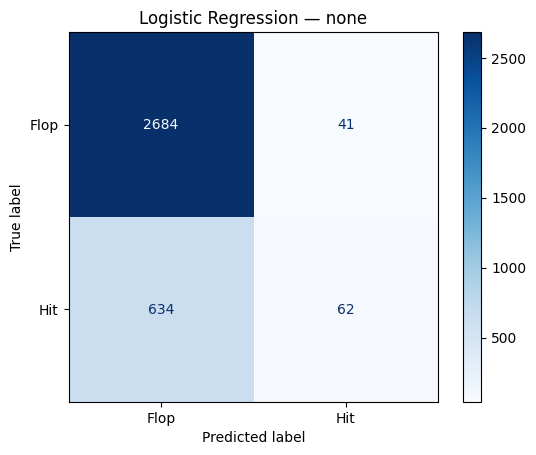

{'model': 'logistic_regression',
 'resample': 'none',
 'roc_auc': np.float64(0.7755132869345144),
 'f1': 0.15519399249061328,
 'accuracy': 0.8026892721426484}

In [14]:
pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

metrics_none, model_none = fit_and_eval(pipe, param_grid, X_train, y_train, X_test, y_test, "none")
metrics_none

## 6. Run 2 — 50/50 train-downsample

Same pipeline and grid, but trained on a class-balanced **subsample of the training set**
(`downsample_50_50`). Evaluated on the same, untouched test set as Run 1 — so the two rows are
directly comparable.

balanced train shape: (5568, 3)  Hit rate: 0.5
--- downsample | best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} ---
              precision    recall  f1-score   support

        Flop       0.92      0.65      0.76      2725
         Hit       0.36      0.77      0.49       696

    accuracy                           0.67      3421
   macro avg       0.64      0.71      0.62      3421
weighted avg       0.80      0.67      0.70      3421



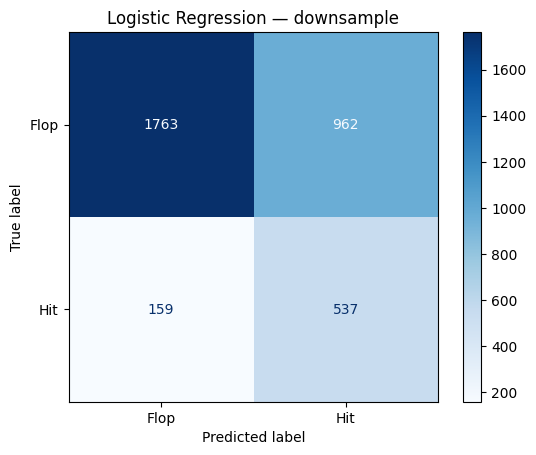

{'model': 'logistic_regression',
 'resample': 'downsample',
 'roc_auc': np.float64(0.7739589265000527),
 'f1': 0.48929384965831435,
 'accuracy': 0.6723180356620871}

In [15]:
X_train_bal, y_train_bal = downsample_50_50(X_train, y_train)
print("balanced train shape:", X_train_bal.shape, " Hit rate:", round(y_train_bal.mean(), 3))

metrics_bal, model_bal = fit_and_eval(pipe, param_grid, X_train_bal, y_train_bal, X_test, y_test, "downsample")
metrics_bal

## 7. Compare runs & save results

Both runs must clear the majority baseline (accuracy ≈ test Hit-rate complement, ROC-AUC = 0.5).
Results appended to `results/logistic_regression.csv` with columns
`model, resample, roc_auc, f1, accuracy` per the shared Phase C contract.

In [16]:
import os
os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame([metrics_none, metrics_bal])[["model", "resample", "roc_auc", "f1", "accuracy"]]
display(results_df)

baseline_auc = 0.5
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority baseline — accuracy: {baseline_acc:.3f}, roc_auc: {baseline_auc:.3f}")
assert (results_df["roc_auc"] > baseline_auc).all(), "A run did not beat the majority baseline (AUC)!"

results_df.to_csv("results/logistic_regression.csv", index=False)
print("Saved -> results/logistic_regression.csv")

,model,resample,roc_auc,f1,accuracy
0,logistic_regression,none,0.775513,0.155194,0.802689
1,logistic_regression,downsample,0.773959,0.489294,0.672318


Majority baseline — accuracy: 0.797, roc_auc: 0.500
Saved -> results/logistic_regression.csv


## 8. Feature importance (coefficients)

Quick look at which one-hot levels / `publisher_tier` push the no-resample model toward "Hit" —
sanity check that `publisher_tier` dominates, consistent with the README's note on the dominant
feature.

,feature,coef
14,onehot__genre_Visual Novel,-2.764105
16,onehot__platform_family_Other,-1.735958
17,onehot__platform_family_PC,-1.187030
20,scale__publisher_tier,1.061874
10,onehot__genre_Shooter,0.659912
13,onehot__genre_Strategy,-0.626485
18,onehot__platform_family_PlayStation,0.553431
7,onehot__genre_Puzzle,-0.506979
1,onehot__genre_Action-Adventure,0.475451
19,onehot__platform_family_Xbox,0.472685


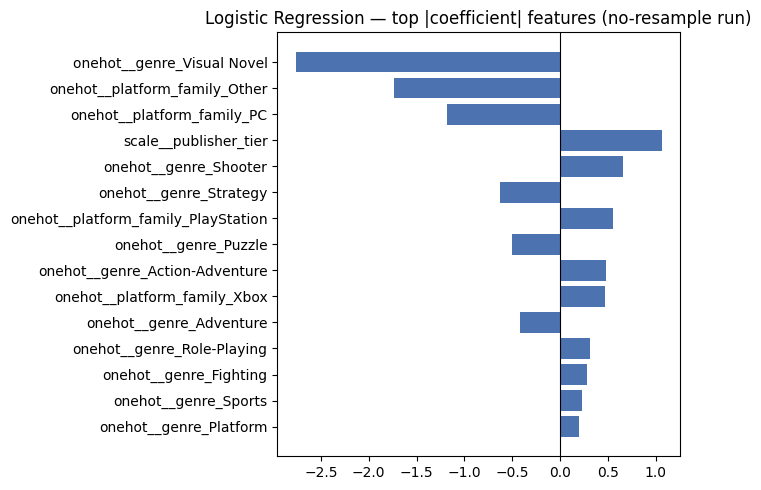

In [17]:
feature_names = model_none.named_steps["prep"].get_feature_names_out()
coefs = model_none.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({"feature": feature_names, "coef": coefs})
           .sort_values("coef", key=abs, ascending=False)
           .head(15))
display(coef_df)

plt.figure(figsize=(7, 5))
plt.barh(coef_df["feature"][::-1], coef_df["coef"][::-1], color="#4C72B0")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — top |coefficient| features (no-resample run)")
plt.tight_layout()
plt.show()

In [18]:
# Final — re-save and show the results table
results_df.to_csv(f"results/logistic_regression.csv", index=False)
print(f"Saved -> results/logistic_regression.csv")
results_df

Saved -> results/logistic_regression.csv


,model,resample,roc_auc,f1,accuracy
0,logistic_regression,none,0.775513,0.155194,0.802689
1,logistic_regression,downsample,0.773959,0.489294,0.672318
